In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = sns.color_palette("viridis", 5)

primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'   # keeping your custom red
neutral_color = viridis_colors[4]

custom_palette = viridis_colors

In [5]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding = 'latin-1')

In [6]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


# Exploratory Data Analysis

In [7]:
print('rows,cols: ', df.shape)
print('\ncolumns: ')
print(df.columns.tolist())
print('\nNum duplicates: ', df.duplicated().sum())
print('\nMissing value top(20): ')
print(df.isna().sum().sort_values(ascending= False).head(20))

rows,cols:  (180519, 53)

columns: 
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produ

In [8]:
# data cleaning
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]
# delete cols which have one value or missing
df = df.drop(columns=columns_to_drop, errors='ignore')

# removing canceled orders since they are not relevant for delivery time analysis and may have different patterns
df = df[df['Delivery Status'] != 'Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [9]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col}, value counts:')
        print(df[col].value_counts())


Type, value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real), value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled), value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status, value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk, value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country, value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment, value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status, value counts:
Order Status
CO

In [10]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [11]:
 # profitability flag based on order profit per order
df['Profitability Flag']= np.where(df['Order Profit Per Order'] > 0 , 'Profit' , np.where(df['Order Profit Per Order'] < 0 , 'Loss' , 'Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [12]:
df['Profitability Flag'].value_counts(normalize = True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break-even    0.00646
Name: proportion, dtype: float64

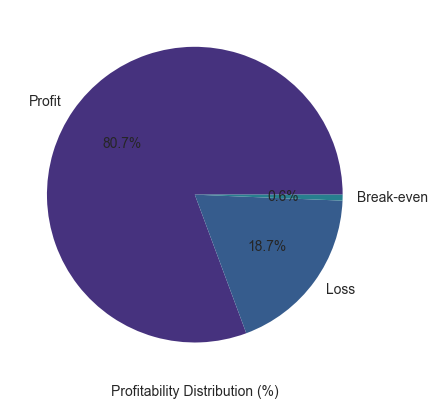

In [33]:
# visualize for profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize = True) * 100
profit_counts.plot(kind = 'pie', autopct = '%1.1f%%')
plt.ylabel('')
plt.xlabel('Profitability Distribution (%)')
plt.savefig("profitability_distribution.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [14]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


# Profitability vs Delivery time analysis

In [16]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    )
    .reset_index()
)
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [17]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize = True)
    .sort_index() * 100
).reset_index()
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


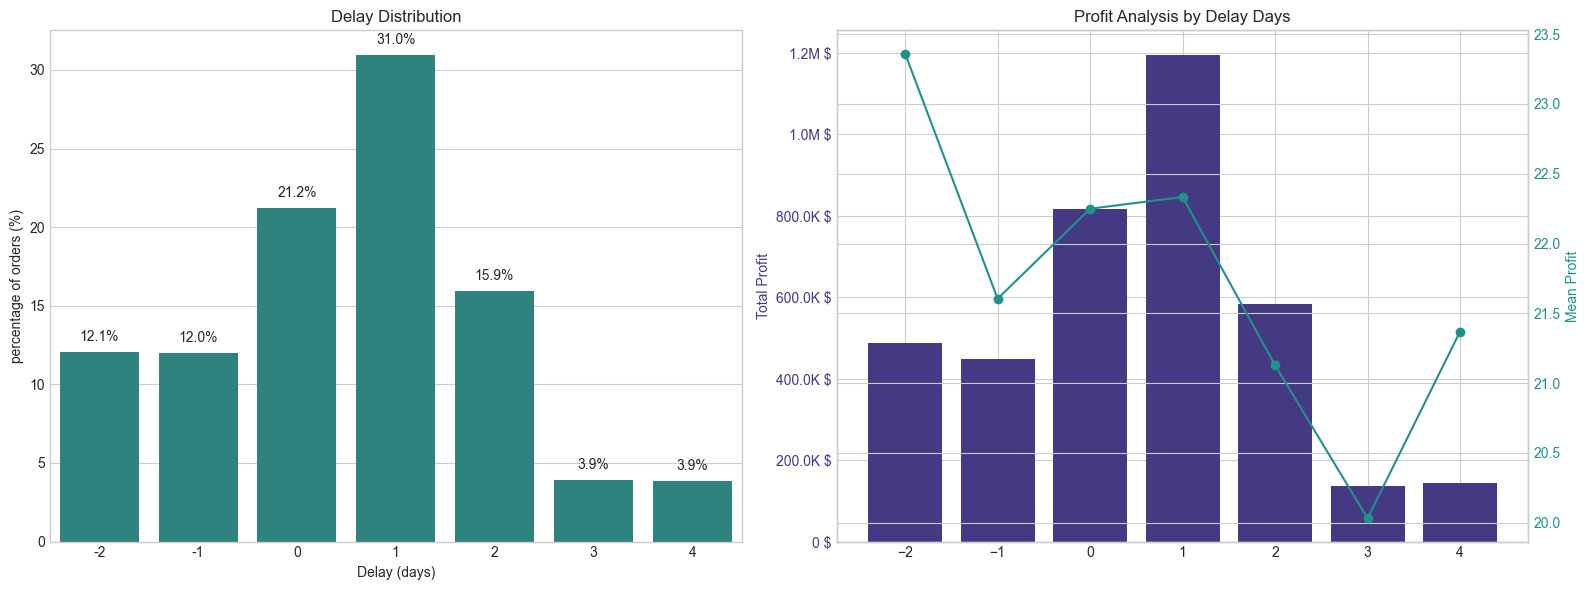

In [34]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')


# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)


# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

plt.tight_layout()
plt.savefig("delay_profit_analysis.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Bottleneck detection

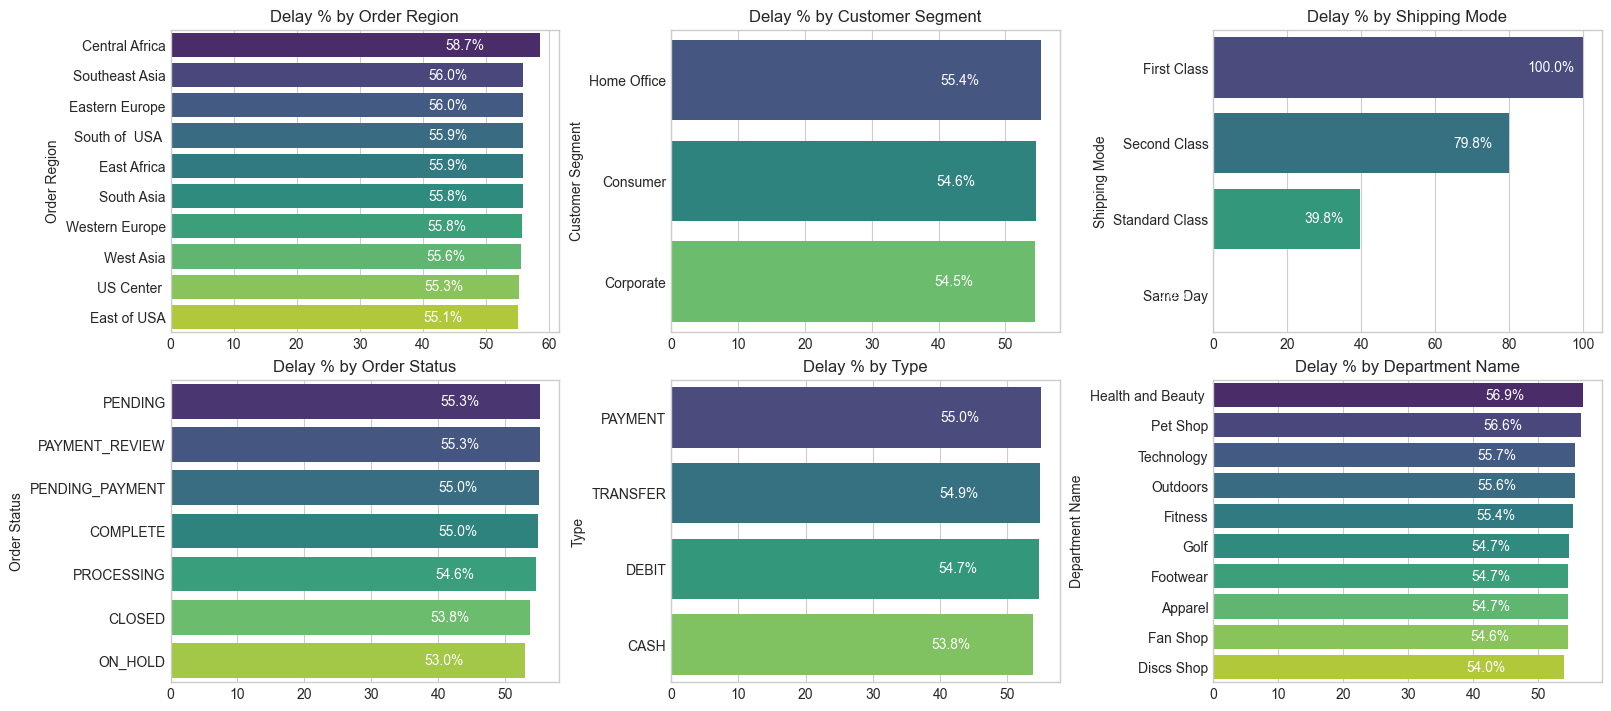

In [35]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df



categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()


for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'   
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )
plt.savefig("bottleneck_detection.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    final_df = pd.concat(all_factors)

    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    plt.figure(figsize=(8,6))

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Driver Factors')
    plt.title(f"Top drivers of Late delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)

    plt.gca().invert_yaxis()

    # labels on bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 5,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.show()

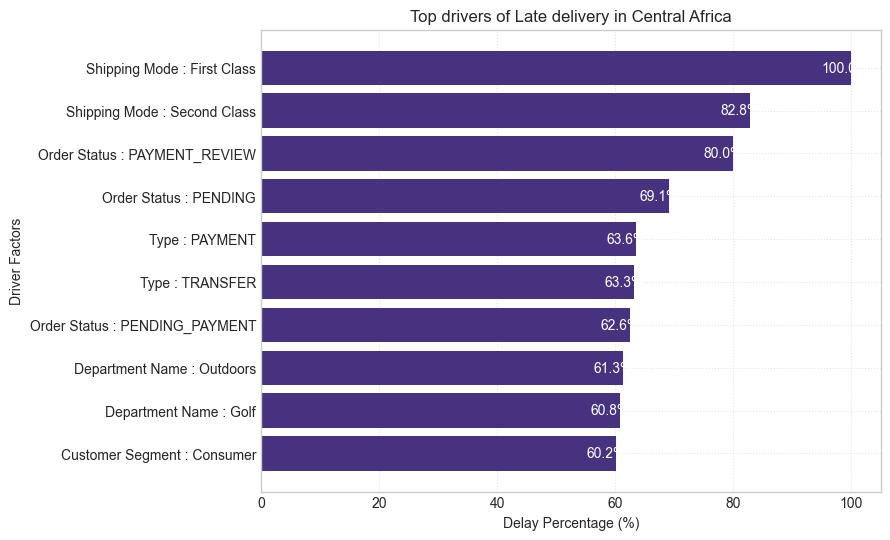

In [21]:
top_drivers_for_region('Central Africa')

In [24]:
# convert to datetime (if not already done)
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')

# create time-based features
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

In [25]:
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100


delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100


delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [30]:
import calendar

delay_by_month['month_name'] = delay_by_month['order_month'].apply(lambda x: calendar.month_abbr[x])

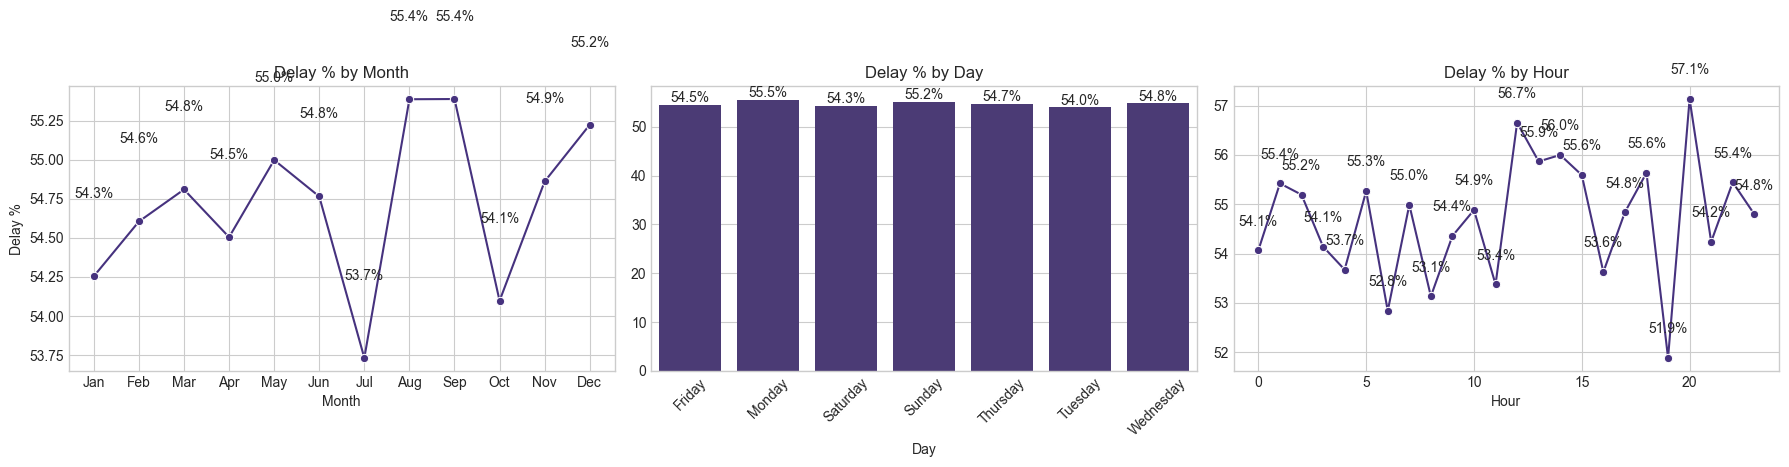

In [36]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. Month-wise Delay
# =========================
sns.lineplot(
    data=delay_by_month,
    x='month_name',
    y='delay_pct',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Delay % by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Delay %')

for i, row in delay_by_month.iterrows():
    axes[0].text(
        i,
        row['delay_pct'] + 0.5,
        f"{row['delay_pct']:.1f}%",
        ha='center'
    )

# =========================
# 2. Day-wise Delay
# =========================
sns.barplot(
    data=delay_by_day,
    x='order_day',
    y='delay_pct',
    ax=axes[1]
)

axes[1].set_title('Delay % by Day')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('')

axes[1].tick_params(axis='x', rotation=45)

for i, row in delay_by_day.iterrows():
    axes[1].text(i, row['delay_pct'] + 0.5, f"{row['delay_pct']:.1f}%", ha='center')


# =========================
# 3. Hour-wise Delay
# =========================
sns.lineplot(
    data=delay_by_hour,
    x='order_hour',
    y='delay_pct',
    marker='o',
    ax=axes[2]
)

axes[2].set_title('Delay % by Hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('')

for i, row in delay_by_hour.iterrows():
    axes[2].text(row['order_hour'], row['delay_pct'] + 0.5, f"{row['delay_pct']:.1f}%", ha='center')


# =========================
# Final touch
# =========================
plt.tight_layout()
plt.savefig("delay_by_time.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [32]:
print("📊 FINAL SUMMARY")
print("----------------------------")
print("• Identified key delay patterns across time, region, and shipping mode")
print("• Detected major bottlenecks affecting delivery performance")
print("• Quantified financial impact of delays on profit")
print("• Suggested actionable improvements to optimize supply chain efficiency")

📊 FINAL SUMMARY
----------------------------
• Identified key delay patterns across time, region, and shipping mode
• Detected major bottlenecks affecting delivery performance
• Quantified financial impact of delays on profit
• Suggested actionable improvements to optimize supply chain efficiency
